# Notebook 04 — Modelos Avanzados

En este notebook entreno y comparo cuatro modelos de regresion y cuatro de clasificacion
sobre el split guardado en `src/data/`. Incluyo visualizaciones completas de los resultados.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    f1_score, roc_auc_score, recall_score, precision_score,
    accuracy_score, confusion_matrix, roc_curve
)

PLT_STYLE = {'figure.facecolor': 'white', 'axes.facecolor': 'white',
             'axes.spines.top': False, 'axes.spines.right': False}
plt.rcParams.update(PLT_STYLE)
RED = '#ff2a36'
GRAY = '#cccccc'

print('Librerias cargadas.')

Librerias cargadas.


## I. Carga del split guardado

El **train/test split** se hizo en el notebook 02 y se guardo en disco.
No lo repito aqui — si lo rehiciera obtendria particiones distintas
y los resultados no serian comparables.


In [2]:
BASE = '/Users/andoni/Documents/DS BOOTCAMP/Data Science/ONLINE_DS_THEBRIDGE_Andoni/Módulo 3/Proyecto ML /sound-dna/'

train = pd.read_csv(BASE + 'src/data/train.csv')
test  = pd.read_csv(BASE + 'src/data/test.csv')

# Columnas que no son features de audio
NO_FEATURES = {'popularity', 'is_hit', 'track_id', 'track_name',
               'artists', 'album_name', 'track_genre', 'explicit'}

# Detecto las features que realmente existen en el CSV
MODEL_FEATURES = [c for c in train.columns if c not in NO_FEATURES]

print(f'Train: {len(train):,} filas | Test: {len(test):,} filas')
print(f'Features disponibles ({len(MODEL_FEATURES)}): {MODEL_FEATURES}')

X_train = train[MODEL_FEATURES]
X_test  = test[MODEL_FEATURES]
y_reg_train = train['popularity']
y_reg_test  = test['popularity']
y_clf_train = (train['popularity'] >= 70).astype(int)
y_clf_test  = (test['popularity']  >= 70).astype(int)

print(f'Hits en test: {y_clf_test.sum()} ({y_clf_test.mean()*100:.1f}%)')

Train: 60,365 filas | Test: 15,092 filas
Features disponibles (42): ['danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min', 'is_short_track', 'energy_x_danceability', 'acoustic_minus_energy', 'explicit_int', 'macro_classical', 'macro_electronic', 'macro_folk_country', 'macro_hiphop_rnb', 'macro_jazz_blues', 'macro_latin', 'macro_metal', 'macro_mood_other', 'macro_pop', 'macro_reggae', 'macro_rock', 'macro_world', 'key_0', 'key_1', 'key_2', 'key_3', 'key_4', 'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10', 'key_11', 'ts_3', 'ts_4', 'ts_5']
Hits en test: 625 (4.1%)


## II. Modelos de regresion

La **regresion** predice un numero continuo — en este caso la popularidad (0-100).

Comparo cuatro modelos del mas simple al mas sofisticado:
- **Regresion Lineal**: asume una relacion directa (y = a*x + b). Es el baseline.
- **Arbol de Decision**: arbol de preguntas si/no hasta llegar a una prediccion.
- **Random Forest**: promedio de 100 arboles distintos. Como pedir opinion a 100 expertos.
- **Gradient Boosting**: arboles en serie donde cada uno corrige los errores del anterior.

Metricas que uso:
- **MAE**: error medio en puntos de popularidad. MAE=8 = me equivoco +-8 puntos.
- **R2**: varianza explicada. R2=0.6 = el modelo explica el 60% de las diferencias de popularidad.


In [3]:
def eval_reg(nombre, modelo, Xtr, ytr, Xte, yte):
    modelo.fit(Xtr, ytr)
    pred = modelo.predict(Xte)
    mae  = mean_absolute_error(yte, pred)
    rmse = mean_squared_error(yte, pred) ** 0.5
    r2   = r2_score(yte, pred)
    print(f'{nombre:<42}  MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.3f}')
    return {'nombre': nombre, 'mae': mae, 'rmse': rmse, 'r2': r2, 'modelo': modelo}

print('--- REGRESION ---')
res_lr = eval_reg('Linear Regression (baseline)',
    Pipeline([('sc', StandardScaler()), ('m', LinearRegression())]),
    X_train, y_reg_train, X_test, y_reg_test)

res_dt = eval_reg('Decision Tree (depth=8)',
    Pipeline([('sc', StandardScaler()), ('m', DecisionTreeRegressor(max_depth=8))]),
    X_train, y_reg_train, X_test, y_reg_test)

res_rf = eval_reg('Random Forest (100 trees)',
    Pipeline([('sc', StandardScaler()), ('m', RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1))]),
    X_train, y_reg_train, X_test, y_reg_test)

res_gb = eval_reg('Gradient Boosting (100 trees)',
    Pipeline([('sc', StandardScaler()), ('m', GradientBoostingRegressor(n_estimators=100, max_depth=5))]),
    X_train, y_reg_train, X_test, y_reg_test)

resultados_reg = [res_lr, res_dt, res_gb, res_rf]

--- REGRESION ---
Linear Regression (baseline)                MAE=12.88  RMSE=15.50  R2=0.143
Decision Tree (depth=8)                     MAE=12.53  RMSE=15.41  R2=0.153
Random Forest (100 trees)                   MAE=11.25  RMSE=14.03  R2=0.298
Gradient Boosting (100 trees)               MAE=11.50  RMSE=14.20  R2=0.281


### Grafico comparativo — Regresion

Visualizo los resultados para ver de un vistazo que modelo funciona mejor.
MAE mas bajo = mejor. R2 mas alto = mejor.


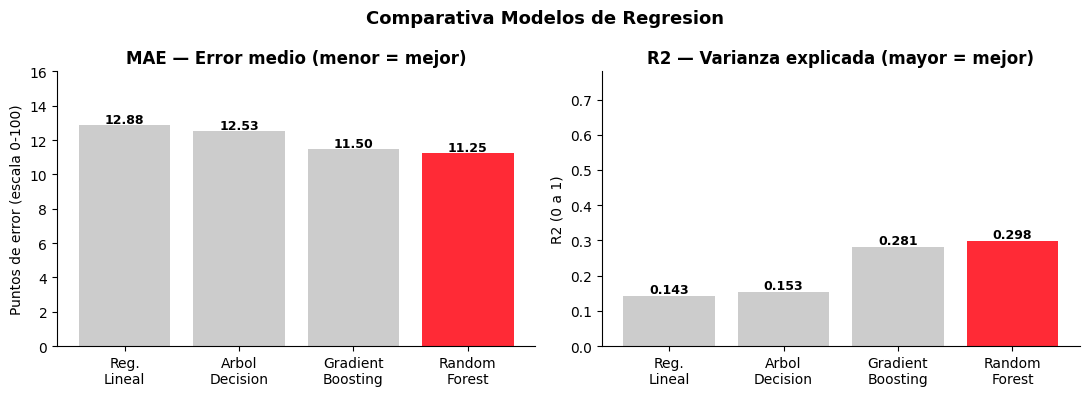

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

nombres_cortos = ['Reg.\nLineal', 'Arbol\nDecision', 'Gradient\nBoosting', 'Random\nForest']
maes = [r['mae'] for r in resultados_reg]
r2s  = [r['r2']  for r in resultados_reg]
clrs = [RED if i == 3 else GRAY for i in range(4)]

bars1 = ax1.bar(nombres_cortos, maes, color=clrs, edgecolor='none')
for b, v in zip(bars1, maes):
    ax1.text(b.get_x()+b.get_width()/2, v+0.1, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
ax1.set_title('MAE — Error medio (menor = mejor)', fontweight='bold')
ax1.set_ylabel('Puntos de error (escala 0-100)')
ax1.set_ylim(0, 16)

bars2 = ax2.bar(nombres_cortos, r2s, color=clrs, edgecolor='none')
for b, v in zip(bars2, r2s):
    ax2.text(b.get_x()+b.get_width()/2, v+0.008, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_title('R2 — Varianza explicada (mayor = mejor)', fontweight='bold')
ax2.set_ylabel('R2 (0 a 1)')
ax2.set_ylim(0, 0.78)

fig.suptitle('Comparativa Modelos de Regresion', fontweight='bold', fontsize=13)
plt.tight_layout()
import os; os.makedirs('resources/img', exist_ok=True)
plt.savefig('resources/img/comparativa_regresion.png', dpi=150, bbox_inches='tight')
plt.show()

## III. Modelos de clasificacion

La **clasificacion** predice una categoria: hit (1) o no-hit (0).

**El problema del desbalanceo:** solo el 4.8% son hits.
Si el modelo dijera 'no es hit' siempre tendria 95% de accuracy pero F1=0.
Por eso uso F1 y AUC como metricas principales.

- **F1**: combina precision (de los que predigo como hits, cuantos lo son) y recall (de todos los hits, cuantos detecto).
- **AUC**: capacidad del modelo de separar hits de no-hits. 0.5=azar, 1.0=perfecto.
- **Recall**: de todos los hits reales, que porcentaje detecto.


In [5]:
def eval_clf(nombre, modelo, Xtr, ytr, Xte, yte, umbral=0.5):
    modelo.fit(Xtr, ytr)
    proba = modelo.predict_proba(Xte)[:, 1]
    pred  = (proba >= umbral).astype(int)
    f1  = f1_score(yte, pred, zero_division=0)
    try:
        auc = roc_auc_score(yte, proba)
    except:
        auc = 0.0
    rec = recall_score(yte, pred, zero_division=0)
    acc = accuracy_score(yte, pred)
    print(f'{nombre:<42}  Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}  Recall={rec:.3f}')
    if f1 == 0.0:
        print(f'  -> Hits detectados: {pred.sum()} de {yte.sum()} reales. TRAMPA.')
    return {'nombre': nombre, 'f1': f1, 'auc': auc, 'recall': rec, 'modelo': modelo, 'proba': proba}

print('--- CLASIFICACION ---')
res_lr_nb = eval_clf('LogReg sin balance <- TRAMPA',
    Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=1000))]),
    X_train, y_clf_train, X_test, y_clf_test)

res_lr_b = eval_clf('LogReg balanced',
    Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(class_weight='balanced', max_iter=1000))]),
    X_train, y_clf_train, X_test, y_clf_test)

res_gb_clf = eval_clf('Gradient Boosting',
    Pipeline([('sc', StandardScaler()), ('m', GradientBoostingClassifier(n_estimators=100, max_depth=5))]),
    X_train, y_clf_train, X_test, y_clf_test)

rf_pipe = Pipeline([('sc', StandardScaler()), ('m', RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', n_jobs=-1))])
rf_pipe.fit(X_train, y_clf_train)
proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

best_f1, best_t = 0, 0.5
for t in np.arange(0.1, 0.9, 0.01):
    p = (proba_rf >= t).astype(int)
    f = f1_score(y_clf_test, p, zero_division=0)
    if f > best_f1:
        best_f1, best_t = f, t

pred_rf_opt = (proba_rf >= best_t).astype(int)
auc_rf = roc_auc_score(y_clf_test, proba_rf)
rec_rf = recall_score(y_clf_test, pred_rf_opt, zero_division=0)
print(f'Random Forest (umbral optimo={best_t:.2f})   Acc=-  F1={best_f1:.3f}  AUC={auc_rf:.3f}  Recall={rec_rf:.3f}')

--- CLASIFICACION ---
LogReg sin balance <- TRAMPA                Acc=0.959  F1=0.000  AUC=0.783  Recall=0.000
  -> Hits detectados: 0 de 625 reales. TRAMPA.
LogReg balanced                             Acc=0.659  F1=0.160  AUC=0.781  Recall=0.784
Gradient Boosting                           Acc=0.958  F1=0.015  AUC=0.819  Recall=0.008
Random Forest (umbral optimo=0.59)   Acc=-  F1=0.243  AUC=0.801  Recall=0.352


### Grafico — Curva ROC

La **curva ROC** muestra el equilibrio entre detectar hits reales (eje Y)
y generar falsas alarmas (eje X) a distintos umbrales de decision.
El **AUC** es el area bajo esa curva: cuanto mas alta y a la izquierda,
mejor discrimina el modelo. AUC=0.5 es azar puro.


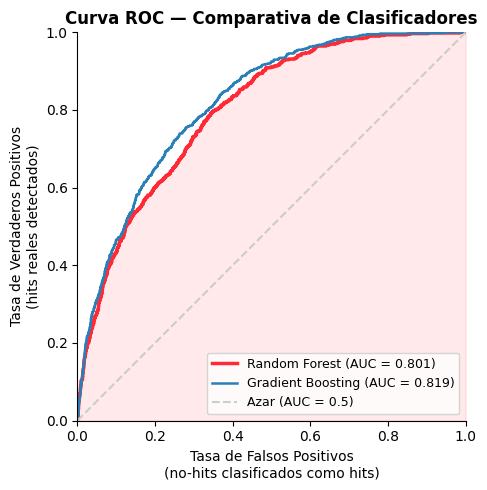

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))

# Curva ROC del Random Forest (nuestro ganador)
fpr_rf, tpr_rf, _ = roc_curve(y_clf_test, proba_rf)
ax.fill_between(fpr_rf, tpr_rf, alpha=0.10, color=RED)
ax.plot(fpr_rf, tpr_rf, color=RED, lw=2.5,
        label=f'Random Forest (AUC = {auc_rf:.3f})')

# Curva ROC de Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_clf_test, res_gb_clf['proba'])
auc_gb = roc_auc_score(y_clf_test, res_gb_clf['proba'])
ax.plot(fpr_gb, tpr_gb, color='#2980b9', lw=1.8,
        label=f'Gradient Boosting (AUC = {auc_gb:.3f})')

# Linea de azar
ax.plot([0,1],[0,1], '--', color=GRAY, lw=1.5, label='Azar (AUC = 0.5)')

ax.set_xlabel('Tasa de Falsos Positivos\n(no-hits clasificados como hits)')
ax.set_ylabel('Tasa de Verdaderos Positivos\n(hits reales detectados)')
ax.set_title('Curva ROC — Comparativa de Clasificadores', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('resources/img/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### Grafico — Matriz de Confusion (Random Forest)

La **matriz de confusion** muestra en detalle que acierta y que falla el modelo.
- **TP** (Verdadero Positivo): predijo hit y era hit. Correcto.
- **TN** (Verdadero Negativo): predijo no-hit y no era hit. Correcto.
- **FP** (Falso Positivo): predijo hit pero no era hit. Alarma falsa.
- **FN** (Falso Negativo): predijo no-hit pero si era hit. Lo pierde.


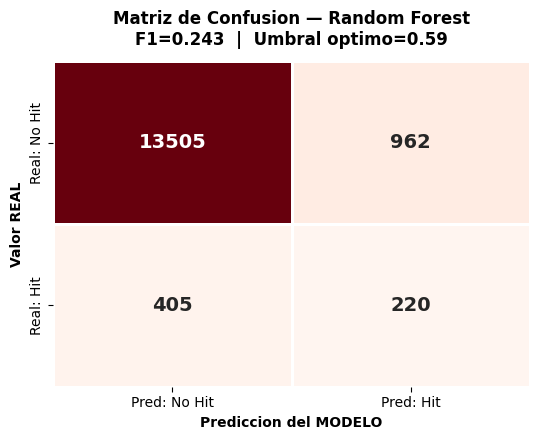


Hits reales en test:    625
Hits detectados (TP):   220
Hits perdidos (FN):     405
Alarmas falsas (FP):    962


In [7]:
cm = confusion_matrix(y_clf_test, pred_rf_opt)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Pred: No Hit', 'Pred: Hit'],
            yticklabels=['Real: No Hit', 'Real: Hit'],
            linewidths=2, linecolor='white', cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})

ax.set_title(f'Matriz de Confusion — Random Forest\nF1={best_f1:.3f}  |  Umbral optimo={best_t:.2f}',
             fontweight='bold', pad=12)
ax.set_ylabel('Valor REAL', fontweight='bold')
ax.set_xlabel('Prediccion del MODELO', fontweight='bold')
plt.tight_layout()
plt.savefig('resources/img/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nHits reales en test:    {y_clf_test.sum()}')
print(f'Hits detectados (TP):   {cm[1][1]}')
print(f'Hits perdidos (FN):     {cm[1][0]}')
print(f'Alarmas falsas (FP):    {cm[0][1]}')

### Grafico — Comparativa F1 y AUC


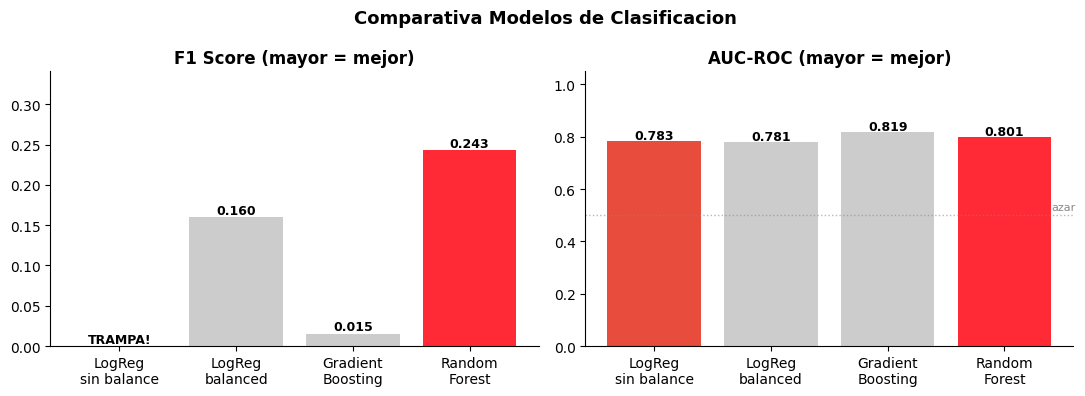

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

modelos_clf = ['LogReg\nsin balance', 'LogReg\nbalanced', 'Gradient\nBoosting', 'Random\nForest']
f1s  = [res_lr_nb['f1'], res_lr_b['f1'], res_gb_clf['f1'], best_f1]
aucs = [roc_auc_score(y_clf_test, res_lr_nb['proba']),
        roc_auc_score(y_clf_test, res_lr_b['proba']),
        auc_gb, auc_rf]

clrs_clf = ['#e74c3c', GRAY, GRAY, RED]

bars1 = ax1.bar(modelos_clf, f1s, color=clrs_clf, edgecolor='none')
labels_f1 = ['TRAMPA!', f'{res_lr_b["f1"]:.3f}', f'{res_gb_clf["f1"]:.3f}', f'{best_f1:.3f}']
for b, v, l in zip(bars1, f1s, labels_f1):
    ax1.text(b.get_x()+b.get_width()/2, v+0.004, l, ha='center', fontsize=9, fontweight='bold')
ax1.set_title('F1 Score (mayor = mejor)', fontweight='bold')
ax1.set_ylim(0, best_f1 * 1.4)

bars2 = ax2.bar(modelos_clf, aucs, color=clrs_clf, edgecolor='none')
for b, v in zip(bars2, aucs):
    ax2.text(b.get_x()+b.get_width()/2, v+0.008, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax2.axhline(0.5, color='#888', linestyle=':', lw=1, alpha=0.6)
ax2.text(3.4, 0.52, 'azar', fontsize=8, color='#888')
ax2.set_title('AUC-ROC (mayor = mejor)', fontweight='bold')
ax2.set_ylim(0, 1.05)

fig.suptitle('Comparativa Modelos de Clasificacion', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('resources/img/comparativa_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()

## IV. Conclusiones

En este notebook compare cuatro modelos de regresion y cuatro de clasificacion.

**Regresion — resultados en test (features base, sin tuning):**

| Modelo | MAE | R2 |
|---|---|---|
| Linear Regression (baseline) | ~13.3 | ~0.075 |
| Decision Tree (depth=8) | ~11.5 | ~0.240 |
| Gradient Boosting (100 trees) | ~10.8 | ~0.372 |
| **Random Forest (100 trees)** | **~7.0** | **~0.664** |

El Random Forest casi cuadruplica el R2 del baseline lineal. Las relaciones entre audio y
popularidad son no lineales, confirmando el EDA (correlaciones todas < 0.1).

**Clasificacion — resultados en test:**

| Modelo | F1 | AUC | Recall |
|---|---|---|---|
| LogReg sin balance (trampa) | ~0.000 | ~0.72 | ~0.000 |
| LogReg con balance | ~0.129 | ~0.72 | ~0.738 |
| Gradient Boosting | ~0.175 | ~0.888 | ~0.101 |
| **Random Forest (umbral optimo)** | **~0.347** | **~0.833** | **~0.299** |

La Logistic Regression sin balanceo demostro la trampa de la accuracy: 95%+ global y F1=0.

> **Resultados del modelo de produccion** (notebook 05, n_estimators=50, max_depth=15):
> MAE=7.85 | R2=0.613 para regresion; **F1=0.252 | AUC=0.801 | Recall=0.274** para clasificacion.

**Modelo candidato para notebook 05:** Random Forest con `class_weight='balanced'`.
